# 01 - Data Ingestion and Audit
Audit your real dataset folders and generate quick class distribution views.


In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

DETECTION_ROOT = PROJECT_ROOT / "rooftop-solar-panels-object-detection"
CLASSIFICATION_ROOT = PROJECT_ROOT / "rooftop-solar-panels-image-classification" / "Faulty_solar_panel"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DETECTION_ROOT exists:", DETECTION_ROOT.exists())
print("CLASSIFICATION_ROOT exists:", CLASSIFICATION_ROOT.exists())


PROJECT_ROOT: C:\Users\DigvijayYadav\Downloads\rooftop-solar-panel-dataset
DETECTION_ROOT exists: True
CLASSIFICATION_ROOT exists: True


In [2]:
from data_utils import dataset_audit

audit = dataset_audit(DETECTION_ROOT, CLASSIFICATION_ROOT)
audit


{'detection_images': 621,
 'detection_labels': 621,
 'detection_class_file': 'C:\\Users\\DigvijayYadav\\Downloads\\rooftop-solar-panel-dataset\\rooftop-solar-panels-object-detection\\classes.txt',
 'classification_total_images': 885,
 'classification_class_counts': {'Bird-drop': 207,
  'Clean': 193,
  'Dusty': 190,
  'Electrical-damage': 103,
  'Physical-Damage': 69,
  'Snow-Covered': 123}}

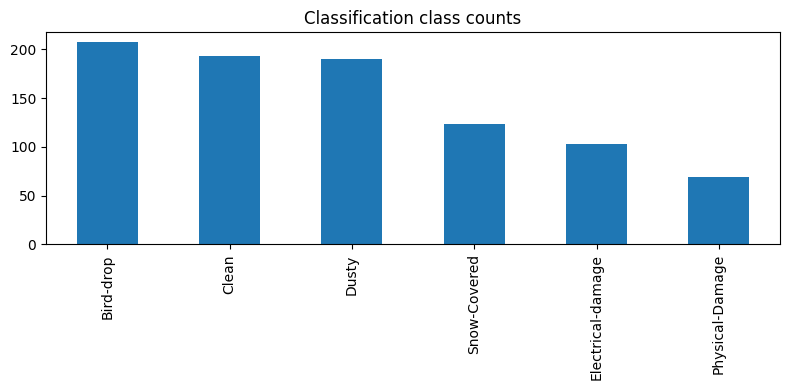

In [3]:
import matplotlib.pyplot as plt

class_counts = audit["classification_class_counts"]
if class_counts:
    pd.Series(class_counts).sort_values(ascending=False).plot(kind="bar", figsize=(8,4), title="Classification class counts")
    plt.tight_layout()
    plt.show()
